In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
WORK = '/kaggle/working'

def find(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    assert len(hits) == 1, (name, hits)
    return hits[0]

BASE = os.path.dirname(find('train.csv'))
test = pd.read_csv(f'{BASE}/test.csv')
folds = pd.read_csv(find('folds.csv'))
fg = pd.read_csv(find('folds_group.csv'))
folds = folds.merge(fg[['uid', 'g120', 'g250']], on='uid', how='left')
assert folds[['g120', 'g250']].isna().sum().sum() == 0
te_uids = ['test/' + f for f in test.filename]

TF = pd.read_csv(find('text_features.csv'), index_col='uid')
TF_tr, TF_te = TF.loc[folds.uid], TF.loc[te_uids]
LS = pd.read_csv(find('llm_scores.csv')).set_index('uid')
llm_cols = ['e', 'ent'] + [f'p{k}' for k in range(1, 6)] + [f'l{k}' for k in range(1, 6)]
LS_tr, LS_te = LS.loc[folds.uid, llm_cols], LS.loc[te_uids, llm_cols]

Q = pd.read_csv(find('llm14_scores.csv')).set_index('uid')
q_ids = pd.read_csv(find('llm14_uids.csv')).uid.tolist()
assert q_ids == Q.index.tolist(), 'llm14 uid order mismatch'
q_cols = ['e', 'ent', 'p1', 'p2', 'p3', 'p4', 'p5']
Q_tr, Q_te = Q.loc[folds.uid, q_cols], Q.loc[te_uids, q_cols]
print('14B scalars:', Q_tr.shape, '| NaN:', int(Q[q_cols].isna().sum().sum()))

def load_emb(emb_file, uid_file):
    E = np.load(find(emb_file), mmap_mode='r')
    ids = pd.read_csv(find(uid_file)).uid.tolist()
    ix = {u: i for i, u in enumerate(ids)}
    tr = np.array([ix[u] for u in folds.uid])
    te = np.array([ix[u] for u in te_uids])
    return E, tr, te

EW, w_tr, w_te = load_emb('wavlm_large_mean.npy', 'wavlm_uids.csv')
EH, h_tr, h_te = load_emb('whisper_enc_mean.npy', 'whisper_enc_uids.csv')
E7, s_tr, s_te = load_emb('llm_rubric_meanpool.npy', 'llm_views_uids.csv')
E14, q_tr, q_te = load_emb('llm14_meanpool.npy', 'llm14_uids.csv')
print('shapes:', EW.shape, EH.shape, E7.shape, E14.shape)

y = folds.label.values
w = folds.w_test.values
nz = (folds.is_zero == 0).values
grp = folds.dur_group.values

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pear(a, b): return float(np.corrcoef(a, b)[0, 1])
def wrmse(a, b, ww): return float(np.sqrt(np.sum(ww * (a - b) ** 2) / np.sum(ww)))
def wpear(a, b, ww):
    ma, mb = np.average(a, weights=ww), np.average(b, weights=ww)
    return float(np.sum(ww * (a - ma) * (b - mb)) /
                 np.sqrt(np.sum(ww * (a - ma) ** 2) * np.sum(ww * (b - mb) ** 2)))

def report(oof):
    r = {'non_zero': (rmse(y[nz], oof[nz]), pear(y[nz], oof[nz]))}
    for g in ['dur_45s', 'dur_60s']:
        m = nz & (grp == g)
        r[g] = (rmse(y[m], oof[m]), pear(y[m], oof[m]))
    r['test_weighted'] = (wrmse(y[nz], oof[nz], w[nz]), wpear(y[nz], oof[nz], w[nz]))
    return pd.DataFrame(r, index=['RMSE', 'Pearson']).T.round(4)

def score(oof):
    r = report(oof)
    rm, pe = r.loc['test_weighted', 'RMSE'], r.loc['test_weighted', 'Pearson']
    return dict(rmse_w=rm, pear_w=pe, proxy=(rm + 1 - pe) / 2,
                pear_45=r.loc['dur_45s', 'Pearson'], pear_60=r.loc['dur_60s', 'Pearson'])

FOLD_COLS = ['g250', 'g120']
bo = pd.read_csv(find('base3_oof.csv')).set_index('uid').reindex(folds.uid)
bt = pd.read_csv(find('base3_test.csv')).set_index('filename').reindex(test.filename)
names0 = sorted({c.split('__')[0] for c in bo.columns})
R = {n: dict(oof={c: bo[f'{n}__{c}'].values for c in FOLD_COLS}, test=bt[n].values) for n in names0}
print('base models from notebook 12:', names0)
W_, H_, TL2 = 'wavlm_L21_ridge', 'whisper_L30_ridge', 'text_llm2_ridge'
MP7 = [n for n in names0 if n.startswith('llm_meanpool_L')][0]
L7 = int(MP7.split('_L')[1].split('_')[0])
POOL7, POOL14 = [6, 9, 12, 16, 20, 24], [10, 15, 21, 27, 34, 41]
assert E7.shape[1] == len(POOL7) and E14.shape[1] == len(POOL14)

def avg_oof(names, col): return np.mean([R[n]['oof'][col] for n in names], axis=0)
def avg_test(names): return np.mean([R[n]['test'] for n in names], axis=0)
ref_names = [W_, H_, TL2, MP7]
print('integrity avg|W+H+TL2+MP proxy g250/g120 (expect 0.3607 / 0.3636):',
      round(score(avg_oof(ref_names, 'g250'))['proxy'], 4), round(score(avg_oof(ref_names, 'g120'))['proxy'], 4))

14B scalars: (769, 7) | NaN: 0
shapes: (985, 25, 1024) (985, 33, 1280) (985, 6, 3584) (985, 6, 5120)
base models from notebook 12: ['llm_hidden_L9_ridge', 'llm_meanpool_L16_ridge', 'llm_scalar_ridge', 'text_all_ridge', 'text_llm2_ridge', 'text_llm_ridge', 'text_noconf_ridge', 'textnoconf_llm2_ridge', 'textnoconf_llm_ridge', 'views_ridge', 'wavlm_L21_ridge', 'whisper_L30_ridge']
integrity avg|W+H+TL2+MP proxy g250/g120 (expect 0.3607 / 0.3636): 0.3607 0.3636


In [2]:
# S2: 14B mean-pool sweep and new text model
class Winsor(BaseEstimator, TransformerMixin):
    def __init__(self, lo=1, hi=99):
        self.lo, self.hi = lo, hi
    def fit(self, X, y=None):
        self.lo_ = np.percentile(X, self.lo, axis=0)
        self.hi_ = np.percentile(X, self.hi, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def ridge_text():
    return make_pipeline(SimpleImputer(strategy='median'), Winsor(), StandardScaler(),
                         RidgeCV(alphas=np.logspace(-1, 4, 12)))
def ridge_hid():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 6, 11)))
def ridge_wavlm():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 9)))
def svr_head():
    return make_pipeline(StandardScaler(), PCA(n_components=128, random_state=0), SVR(C=3.0, epsilon=0.2, gamma='scale'))

def cv_oof(X, col, make_model):
    oof = np.full(len(y), np.nan)
    for f in range(5):
        va = (folds[col] == f).values
        m = make_model().fit(X[(~va) & nz], y[(~va) & nz])
        oof[va & nz] = np.clip(m.predict(X[va & nz]), 1, 5)
    return oof

def run(name, X_tr, X_te, make_model):
    X_tr, X_te = np.asarray(X_tr, dtype=np.float32), np.asarray(X_te, dtype=np.float32)
    oof = {c: cv_oof(X_tr, c, make_model) for c in FOLD_COLS}
    m = make_model().fit(X_tr[nz], y[nz])
    R[name] = dict(oof=oof, test=np.clip(m.predict(X_te), 1, 5))
    s, s2 = score(oof['g250']), score(oof['g120'])
    return dict(model=name, proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60'],
                train_rmse=rmse(y[nz], np.clip(m.predict(X_tr[nz]), 1, 5)))

# integrity: refit the 7B mean-pool ridge and compare with notebook 12
j7 = POOL7.index(L7)
chk = cv_oof(np.asarray(E7[s_tr, j7], dtype=np.float32), 'g250', ridge_hid)
print('integrity, 7B mean-pool oof vs notebook 12: max abs diff', round(float(np.nanmax(np.abs(chk - R[MP7]['oof']['g250']))), 5))

sw = []
for j, L in enumerate(POOL14):
    X = np.asarray(E14[q_tr, j], dtype=np.float32)
    s1, s2 = score(cv_oof(X, 'g250', ridge_hid)), score(cv_oof(X, 'g120', ridge_hid))
    sw.append(dict(layer=L, j=j, proxy_mean=(s1['proxy'] + s2['proxy']) / 2, pear_w=s1['pear_w'],
                   rmse_w=s1['rmse_w'], pear_45=s1['pear_45'], pear_60=s1['pear_60']))
sw = pd.DataFrame(sw).round(4)
print('14B mean-pooled hidden state by layer (7B layer 16 had mean proxy 0.4221):')
print(sw.drop(columns='j').to_string(index=False))
bj = int(sw.sort_values('proxy_mean').iloc[0].j)
bL = POOL14[bj]
M14 = f'llm14_meanpool_L{bL}_ridge'

cols = TF.columns.tolist()
conf = [c for c in cols if c.startswith(('wp_', 'seg_logprob', 'max_no_speech'))]
noconf = [c for c in cols if c not in conf]
rows = [run(M14, np.asarray(E14[q_tr, bj], dtype=np.float32), np.asarray(E14[q_te, bj], dtype=np.float32), ridge_hid),
        run('text_llm14_ridge', np.hstack([TF_tr[cols].values, LS_tr.values, Q_tr.values]),
            np.hstack([TF_te[cols].values, LS_te.values, Q_te.values]), ridge_text),
        run('textnoconf_llm14_ridge', np.hstack([TF_tr[noconf].values, LS_tr.values, Q_tr.values]),
            np.hstack([TF_te[noconf].values, LS_te.values, Q_te.values]), ridge_text)]
TL14, TLn14 = 'text_llm14_ridge', 'textnoconf_llm14_ridge'
print('\n', pd.DataFrame(rows).round(4).sort_values('proxy_g250').to_string(index=False))
print('reference, text_llm_ridge (notebook 10): g250 0.4706 | text_llm2_ridge (notebook 12): g250 0.4804')

integrity, 7B mean-pool oof vs notebook 12: max abs diff 0.0
14B mean-pooled hidden state by layer (7B layer 16 had mean proxy 0.4221):
 layer  proxy_mean  pear_w  rmse_w  pear_45  pear_60
    10      0.4496  0.7448  0.6485   0.7055   0.7879
    15      0.4342  0.7574  0.6337   0.7257   0.7940
    21      0.4213  0.7688  0.6210   0.7375   0.8056
    27      0.4298  0.7619  0.6296   0.7263   0.8013
    34      0.4267  0.7678  0.6222   0.7382   0.7972
    41      0.4276  0.7630  0.6287   0.7375   0.7864

                    model  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  train_rmse
llm14_meanpool_L21_ridge      0.4261      0.4164  0.6210  0.7688   0.7375   0.8056      0.3652
        text_llm14_ridge      0.4682      0.4668  0.6663  0.7300   0.6978   0.7624      0.6211
  textnoconf_llm14_ridge      0.4954      0.4896  0.6923  0.7016   0.6694   0.7227      0.6597
reference, text_llm_ridge (notebook 10): g250 0.4706 | text_llm2_ridge (notebook 12): g250 0.4804


In [3]:
# S3: SVR heads and combo of ridge
heads = [('wavlm', W_, EW, w_tr, w_te, 21, ridge_wavlm),
         ('whisper', H_, EH, h_tr, h_te, 30, ridge_hid),
         ('llm7_meanpool', MP7, E7, s_tr, s_te, j7, ridge_hid),
         ('llm14_meanpool', M14, E14, q_tr, q_te, bj, ridge_hid)]
rows = []
MIX = {}
for label, rname, E, tr_ix, te_ix, L, _ in heads:
    sname = f'{label}_svr'
    rows.append(run(sname, np.asarray(E[tr_ix, L], dtype=np.float32), np.asarray(E[te_ix, L], dtype=np.float32), svr_head))
    mname = f'{label}_mix'
    R[mname] = dict(oof={c: (R[rname]['oof'][c] + R[sname]['oof'][c]) / 2 for c in FOLD_COLS},
                    test=(R[rname]['test'] + R[sname]['test']) / 2)
    MIX[rname] = mname
    s, s2 = score(R[mname]['oof']['g250']), score(R[mname]['oof']['g120'])
    rows.append(dict(model=mname, proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'], pear_w=s['pear_w'],
                     pear_45=s['pear_45'], pear_60=s['pear_60'], train_rmse=np.nan))
    s, s2 = score(R[rname]['oof']['g250']), score(R[rname]['oof']['g120'])
    rows.append(dict(model=rname + ' (ridge, for comparison)', proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                     pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60'], train_rmse=np.nan))
print(pd.DataFrame(rows).round(4).to_string(index=False))
print('\nSVR is untuned (C=3, epsilon=0.2, PCA 128). A tie or loss against ridge is a valid outcome.')

                                           model  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  train_rmse
                                       wavlm_svr      0.4334      0.4499  0.6315  0.7646   0.7331   0.8075      0.1805
                                       wavlm_mix      0.4136      0.4256  0.6086  0.7813   0.7444   0.8277         NaN
         wavlm_L21_ridge (ridge, for comparison)      0.4184      0.4309  0.6125  0.7758   0.7329   0.8271         NaN
                                     whisper_svr      0.4052      0.4019  0.5974  0.7869   0.7520   0.8237      0.1875
                                     whisper_mix      0.3863      0.3862  0.5763  0.8038   0.7698   0.8398         NaN
       whisper_L30_ridge (ridge, for comparison)      0.3971      0.4025  0.5879  0.7936   0.7553   0.8352         NaN
                               llm7_meanpool_svr      0.4242      0.4256  0.6205  0.7721   0.7463   0.7945      0.1901
                               llm7_meanpool_mix

                      name  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  proxy_mean
 fit|mix: W+H+TL14+MP7+M14      0.3461      0.3547  0.5291  0.8369   0.8139   0.8582      0.3504
fit|mix: W+H+TLn14+MP7+M14      0.3470      0.3554  0.5301  0.8362   0.8134   0.8568      0.3512
 avg|mix: W+H+TL14+MP7+M14      0.3536      0.3548  0.5447  0.8375   0.8142   0.8592      0.3542
avg|mix: W+H+TLn14+MP7+M14      0.3554      0.3566  0.5471  0.8363   0.8138   0.8563      0.3560
       fit|W+H+TL2+MP7+M14      0.3546      0.3642  0.5393  0.8300   0.8031   0.8570      0.3594
           fit|W+H+TL2+M14      0.3567      0.3638  0.5418  0.8283   0.8001   0.8568      0.3602
      fit|W+H+TL14+MP7+M14      0.3546      0.3665  0.5392  0.8301   0.8046   0.8554      0.3606
       avg|W+H+TL2+MP7+M14      0.3604      0.3614  0.5521  0.8313   0.8048   0.8588      0.3609
      fit|ref: W+H+TL2+MP7      0.3551      0.3672  0.5398  0.8296   0.8023   0.8568      0.3612
           avg|W+H+TL2+M14    

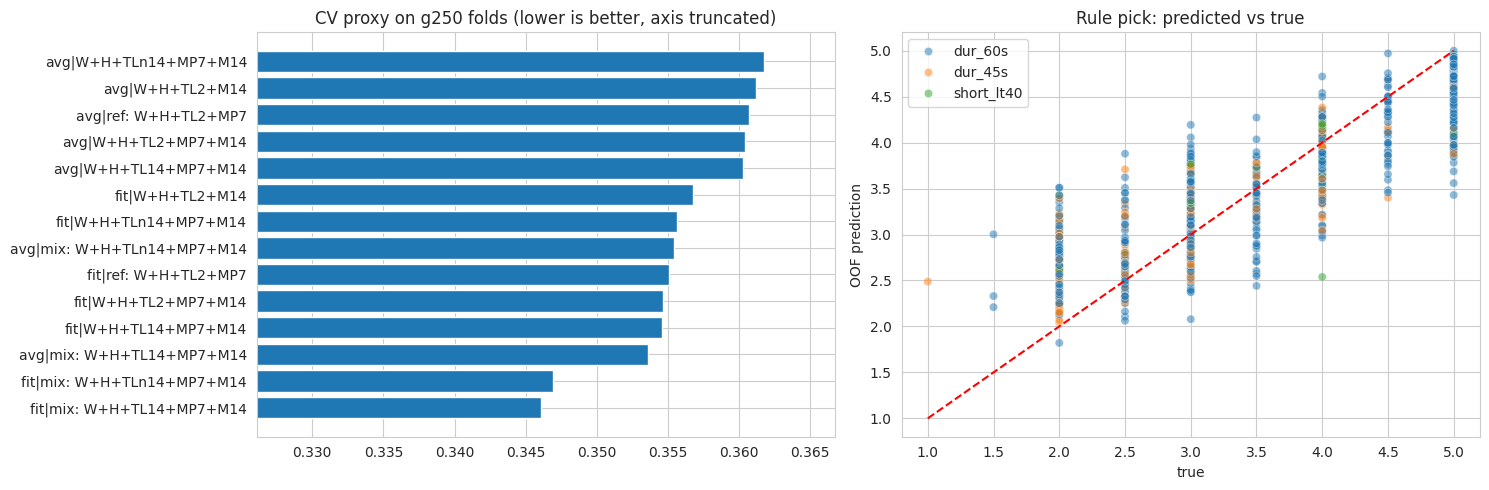

saved submission_stack_v5.csv, base4_oof.csv, base4_test.csv


In [4]:
def blend_cv(names, col, alpha=1.0):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    out = np.full(len(y), np.nan)
    for f in range(5):
        va = (folds[col] == f).values
        m = Ridge(alpha=alpha, positive=True).fit(P[(~va) & nz], y[(~va) & nz])
        out[va & nz] = np.clip(m.predict(P[va & nz]), 1, 5)
    return out

def blend_fit(names, alpha=1.0, col='g250'):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    T = np.column_stack([R[n]['test'] for n in names])
    m = Ridge(alpha=alpha, positive=True).fit(P[nz], y[nz])
    print('  weights', dict(zip(names, np.round(m.coef_, 3))), '| intercept', round(float(m.intercept_), 3))
    return np.clip(m.predict(T), 1, 5)

mx = lambda n: MIX[n]
sets = {'ref: W+H+TL2+MP7': [W_, H_, TL2, MP7],
        'W+H+TL2+MP7+M14': [W_, H_, TL2, MP7, M14],
        'W+H+TL2+M14': [W_, H_, TL2, M14],
        'W+H+TL14+MP7+M14': [W_, H_, TL14, MP7, M14],
        'W+H+TLn14+MP7+M14': [W_, H_, TLn14, MP7, M14],
        'mix: W+H+TL14+MP7+M14': [mx(W_), mx(H_), TL14, mx(MP7), mx(M14)],
        'mix: W+H+TLn14+MP7+M14': [mx(W_), mx(H_), TLn14, mx(MP7), mx(M14)]}
cands = []
for sname, names in sets.items():
    for kind in ['avg', 'fit']:
        o = {c: (avg_oof(names, c) if kind == 'avg' else blend_cv(names, c)) for c in FOLD_COLS}
        s, s2 = score(o['g250']), score(o['g120'])
        cands.append(dict(name=f'{kind}|{sname}', kind=kind, n=len(names), names=names, oof=o,
                          proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                          pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60']))
res = pd.DataFrame([{k: v for k, v in c.items() if k not in ('names', 'oof')} for c in cands])
res['proxy_mean'] = (res.proxy_g250 + res.proxy_g120) / 2
print(res.drop(columns=['kind', 'n']).round(4).sort_values('proxy_mean').to_string(index=False))

best = res.proxy_mean.min()
ok = res[res.proxy_mean <= best + 0.005].copy()
ok['is_fit'] = (ok.kind == 'fit').astype(int)
pick = ok.sort_values(['is_fit', 'n', 'proxy_mean']).iloc[0]
ch = next(c for c in cands if c['name'] == pick['name'])
bst = next(c for c in cands if c['name'] == res.sort_values('proxy_mean').iloc[0]['name'])
ref = next(c for c in cands if c['name'] == 'avg|ref: W+H+TL2+MP7')
print('\nbest mean proxy:', round(best, 4), '| best candidate:', bst['name'], '| rule pick (simplest within 0.005):', ch['name'])
print(report(ch['oof']['g250']))

rng = np.random.RandomState(0)
idx_nz = np.where(nz)[0]
def proxy_on(o, ix):
    return (wrmse(y[ix], o[ix], w[ix]) + 1 - wpear(y[ix], o[ix], w[ix])) / 2
def boot_diff(o_a, o_b, n=500):
    d = np.array([proxy_on(o_a, ix) - proxy_on(o_b, ix)
                  for ix in (rng.choice(idx_nz, len(idx_nz), replace=True) for _ in range(n))])
    return round(float(d.mean()), 4), round(float(np.percentile(d, 5)), 4), round(float(np.percentile(d, 95)), 4)
print('\npaired bootstrap on g250 OOF vs the notebook 12 pick, proxy difference (negative = candidate better): mean, 5th, 95th')
print('  rule pick:', boot_diff(ch['oof']['g250'], ref['oof']['g250']))
print('  best     :', boot_diff(bst['oof']['g250'], ref['oof']['g250']))
print('  (rows are resampled, so cluster dependence and the choice among candidates are ignored: intervals are too narrow)')

pred_te = avg_test(ch['names']) if ch['kind'] == 'avg' else blend_fit(ch['names'])
print('\ntest pred summary:', pd.Series(pred_te).describe().round(3).to_dict())
print('corr with the notebook 12 pick test preds:', round(pear(pred_te, avg_test(ref_names)), 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
allp = res[['name', 'proxy_g250']].sort_values('proxy_g250')
ax[0].barh(allp.name, allp.proxy_g250)
ax[0].set_xlim(allp.proxy_g250.min() - 0.02, allp.proxy_g250.max() + 0.005)
ax[0].set_title('CV proxy on g250 folds (lower is better, axis truncated)')
sns.scatterplot(x=y[nz], y=ch['oof']['g250'][nz], hue=grp[nz], alpha=0.5, ax=ax[1])
ax[1].plot([1, 5], [1, 5], 'r--'); ax[1].set_xlabel('true'); ax[1].set_ylabel('OOF prediction')
ax[1].set_title('Rule pick: predicted vs true')
plt.tight_layout(); plt.show()

bp = pd.DataFrame({'uid': folds.uid})
for n in R:
    for c in FOLD_COLS:
        bp[f'{n}__{c}'] = R[n]['oof'][c]
bp.to_csv(f'{WORK}/base4_oof.csv', index=False)
pd.DataFrame({'filename': test.filename, **{n: R[n]['test'] for n in R}}).to_csv(f'{WORK}/base4_test.csv', index=False)
pd.DataFrame({'filename': test.filename, 'label': pred_te}).to_csv(f'{WORK}/submission_stack_v5.csv', index=False)
print('saved submission_stack_v5.csv, base4_oof.csv, base4_test.csv')

In [5]:
need = ['R', 'ch', 'pred_te', 'boot_diff', 'avg_oof', 'avg_test', 'score', 'report', 'ref_names']
missing = [n for n in need if n not in globals()]
assert not missing, f'wrong notebook or S1-S4 not run in this session, missing: {missing}'
assert all(k in R for k in ['wavlm_mix', 'whisper_mix', 'llm7_meanpool_mix', 'llm14_meanpool_mix']), 'S3 has not run in this session'

nt = ['wavlm_mix', 'whisper_mix', 'llm7_meanpool_mix', 'llm14_meanpool_mix']
o_nt = {c: avg_oof(nt, c) for c in FOLD_COLS}
s1, s2 = score(o_nt['g250']), score(o_nt['g120'])
print('avg|mix W+H+MP7+M14 (no text): proxy g250/g120', round(s1['proxy'], 4), round(s2['proxy'], 4),
      '| mean', round((s1['proxy'] + s2['proxy']) / 2, 4))
print('rule pick for comparison: 0.3536 / 0.3548 | mean 0.3542')
print(report(o_nt['g250']))
print('paired bootstrap vs rule pick on g250 (negative = no-text better): mean, 5th, 95th', boot_diff(o_nt['g250'], ch['oof']['g250']))
pred_nt = avg_test(nt)
print('test preds corr with rule pick:', round(pear(pred_nt, pred_te), 4), '| with notebook 12 pick:', round(pear(pred_nt, avg_test(ref_names)), 4))
print('test pred summary:', pd.Series(pred_nt).describe().round(3).to_dict())
pd.DataFrame({'filename': test.filename, 'label': pred_nt}).to_csv(f'{WORK}/submission_stack_v5_notext.csv', index=False)
print('saved submission_stack_v5_notext.csv')

avg|mix W+H+MP7+M14 (no text): proxy g250/g120 0.3512 0.354 | mean 0.3526
rule pick for comparison: 0.3536 / 0.3548 | mean 0.3542
                 RMSE  Pearson
non_zero       0.5380   0.8525
dur_45s        0.5395   0.8151
dur_60s        0.5353   0.8583
test_weighted  0.5398   0.8373
paired bootstrap vs rule pick on g250 (negative = no-text better): mean, 5th, 95th (-0.0026, -0.0092, 0.0041)
test preds corr with rule pick: 0.9955 | with notebook 12 pick: 0.9824
test pred summary: {'count': 216.0, 'mean': 3.305, 'std': 0.783, 'min': 1.729, '25%': 2.697, '50%': 3.24, '75%': 3.748, 'max': 4.98}
saved submission_stack_v5_notext.csv
